# ISOLET Dataset for Voice Recognition
- This is very much similar to the [digit_recog_uint](./vsa_digit_recog_uint.ipynb) program as it follows the same feature-level or ID-level encoding.
- Here we investigate similar trends to which encoding scheme provides the highest accuracy.

In [4]:
# Parameters
import os
import sys
import numpy as np

# Path directories
curr_dir = os.getcwd()
lib_path = curr_dir + "/../../lib"
extract_path = curr_dir + "/../../extract_data"
data_path = curr_dir + "/../../data"
dir_bin_data = data_path + "/isolet"

# Appending other paths for libraries
sys.path.append(lib_path)
sys.path.append(extract_path)

import vsa
import figs
from extract_data_util import download_and_extract, read_data, split_data

## Data Extraction

In [5]:
url = "https://github.com/rgantonio/chronomatica/releases/download/isolet_dataset_v1.0/chronomatica_isolet.tar.gz"

download_and_extract(
    url=url,
    out_dir=data_path,
    delete_archive=True,
)

# Set class list
class_list = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25]

# Read data
X_data = read_data(class_list, dir_bin_data)

# Train and test split
train_test_split = 0.6
train_valid_split = 0.75

X_train_set, X_test_set = split_data(X_data, class_list, split_percent=train_test_split)
X_train_set_src, X_valid_set = split_data(X_train_set, class_list, split_percent=train_valid_split)

Extracting...
Deleted archive: chronomatica_isolet.tar.gz
Extraction complete!


Splitting data: 100%|██████████| 26/26 [00:00<00:00, 13430.04it/s]


## VSA Model
- VSA model is the same feature-level encoding.
- Mathematically we have:

$$ \mathcal{hv}_{\textrm{enc}} = \sum_{i=0}^{N_{\textrm{feat}}=617} \mathcal{hv}_{\textrm{pixel}}[i] \times X[i] $$

- Where $X[i]$ is the feature scalar value.

In [12]:
class isoletVSA(vsa.ModelVSA):
    def encode(self, item_data):
        # Feature length
        item_len = len(item_data)
        # Threshold for binarization
        threshold = item_len // 2
        # Encode hypervector
        encoded_vec = item_data @ self.ortho_im[0:item_len]
        # Binarization
        if self.binarize_encode:
            encoded_vec = vsa.binarize_hv(encoded_vec, threshold, self.hv_type)
        return encoded_vec

# Training, Retraining, and Testing
- This time we add a switch to collect the accuracies in a list varying the HV dimensions

In [14]:
# Parameters
hv_dim_set = [512, 1024, 2048, 4096, 8192]
hv_dim_set_len = len(hv_dim_set)
accuracy_list = np.zeros(hv_dim_set_len)

In [19]:
for hv_dim in hv_dim_set:
    print(f"Running HV Dimension: {hv_dim}")
    # Create the VSA model with target parameters
    isolet_model = isoletVSA(
        hv_size = hv_dim,
        class_list = class_list,
    )

    # CHANGE ME FOR EXPERIMENTATION:
    # Add the following to binarize the encoded value
    isolet_model.binarize_encode = True
    # Add the following to binarize the AM
    isolet_model.binarize_am = True

    # For debug parameters only
    isolet_model.tqdm_train_mode = False
    isolet_model.tqdm_retrain_mode = False
    isolet_model.tqdm_test_mode = False

    # Train the model
    isolet_model.train_model(X_train_set_src)

    # Retraining the model
    isolet_model.retrain_model(X_valid_set)

    # Test the model
    isolet_model.test_model(X_test_set)

    # Save accuracy
    accuracy_list[hv_dim_set.index(hv_dim)] = isolet_model.model_accuracy

for i in range(len(accuracy_list)):
    accuracy_list[i] = accuracy_list[i]*100

accuracy_list

Running HV Dimension: 512
Training complete!
Retraining complete!
Testing complete!
Running HV Dimension: 1024
Training complete!
Retraining complete!
Testing complete!
Running HV Dimension: 2048
Training complete!
Retraining complete!
Testing complete!
Running HV Dimension: 4096
Training complete!
Retraining complete!
Testing complete!
Running HV Dimension: 8192
Training complete!
Retraining complete!
Testing complete!


array([71.04841295, 80.50657262, 85.34786791, 87.07919205, 88.39371593])

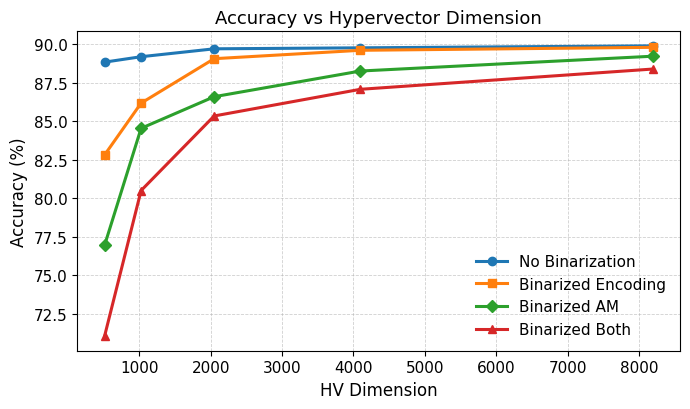

In [20]:
acc = [
    [88.84257775, 89.19525489, 89.70823982, 89.77236294, 89.90060917],
    [82.81500481, 86.18146842, 89.06700866, 89.61205515, 89.8044245 ],
    [76.94773966, 84.54632895, 86.59826868, 88.2654697 , 89.22731645],
    [71.04841295, 80.50657262, 85.34786791, 87.07919205, 88.39371593],
]

hv_dim = [512, 1024, 2048, 4096, 8192]

legend = ['No Binarization', 'Binarized Encoding', 'Binarized AM', 'Binarized Both']
x_label = 'HV Dimension'
y_label = 'Accuracy (%)'
title = 'Accuracy vs Hypervector Dimension'

figs.multiLinePlot(
    x_data=hv_dim,
    y_data_list=acc,
    legend_list=legend,
    x_label=x_label,
    y_label=y_label,
    title=title,
).plot_fig()

In [21]:
isolet_model.print_model_stats()


-----------------
Model Statistics:
-----------------
HV Size: 8192
HV Type: bipolar
Number of Orthogonal IMs: 1024
Number of Continuous IMs: 21
Number of Classes: 26
Binarize Encode: True
Binarize AM: True
Class 0 Accuracy: 90.00%
Class 1 Accuracy: 81.67%
Class 2 Accuracy: 96.67%
Class 3 Accuracy: 85.00%
Class 4 Accuracy: 80.83%
Class 5 Accuracy: 94.96%
Class 6 Accuracy: 90.00%
Class 7 Accuracy: 97.50%
Class 8 Accuracy: 94.17%
Class 9 Accuracy: 91.67%
Class 10 Accuracy: 89.17%
Class 11 Accuracy: 94.17%
Class 12 Accuracy: 84.17%
Class 13 Accuracy: 80.83%
Class 14 Accuracy: 93.33%
Class 15 Accuracy: 71.67%
Class 16 Accuracy: 95.00%
Class 17 Accuracy: 97.50%
Class 18 Accuracy: 95.00%
Class 19 Accuracy: 76.67%
Class 20 Accuracy: 90.83%
Class 21 Accuracy: 63.33%
Class 22 Accuracy: 85.83%
Class 23 Accuracy: 95.83%
Class 24 Accuracy: 93.33%
Class 25 Accuracy: 89.17%
Overall Accuracy: 88.39%


# Some Conclusions
- The conclusion is the same, non-binary gives the best accuracy across dimensions.
- However, it might be wise to use binary encoding but keep AM non-binarized always.